In [ ]:
# 1. Install libraries
!pip install shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import shap
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
df = sns.load_dataset("penguins")

df = df.dropna()

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
X = df[
    [
        "bill_length_mm",
        "bill_depth_mm",
        "flipper_length_mm",
        "body_mass_g"
    ]
]

y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.97        67
   macro avg       0.96      0.97      0.96        67
weighted avg       0.97      0.97      0.97        67



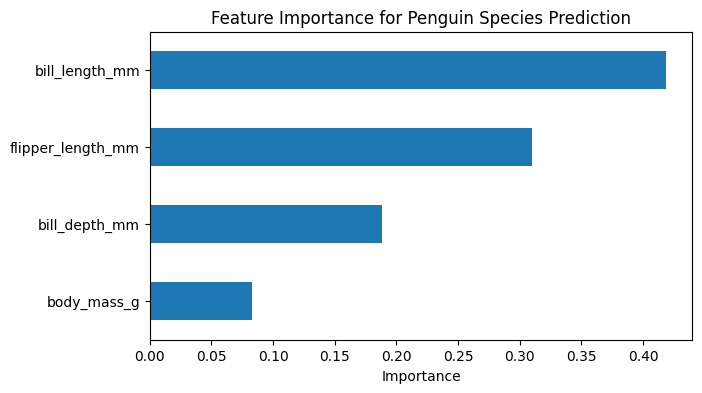

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(7, 4))
importance.plot.barh()
plt.title("Feature Importance for Penguin Species Prediction")
plt.xlabel("Importance")
plt.show()

In [ ]:
example_idx = 0

penguin = X_test.iloc[[example_idx]]
actual_species = y_test.iloc[example_idx]
predicted_species = model.predict(penguin)[0]

display(penguin)

print("Actual species:", actual_species)
print("Predicted species:", predicted_species)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
330,50.5,15.2,216.0,5000.0


Actual species: Gentoo
Predicted species: Gentoo


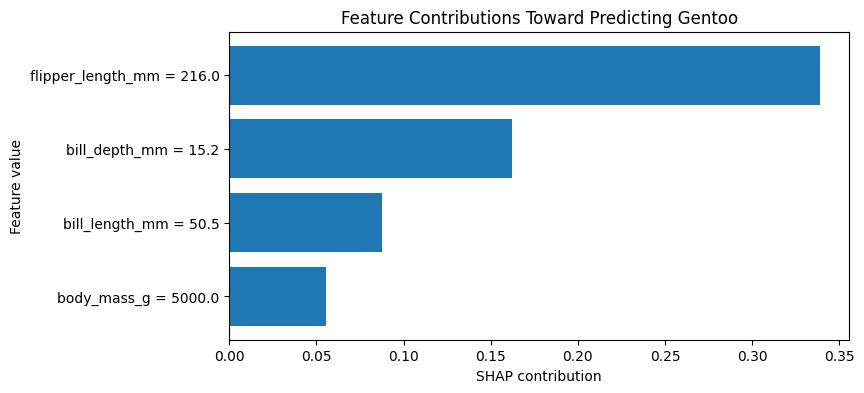

,Feature,Value,SHAP contribution,Label
2,flipper_length_mm,216.0,0.338754,flipper_length_mm = 216.0
1,bill_depth_mm,15.2,0.162261,bill_depth_mm = 15.2
0,bill_length_mm,50.5,0.087361,bill_length_mm = 50.5
3,body_mass_g,5000.0,0.055233,body_mass_g = 5000.0


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# SHAP values for predicted class
feature_names = X.columns.tolist()
feature_values = penguin.iloc[0].values
shap_for_class = shap_values.values[0, :, predicted_class_index]

# Build readable table
explanation_df = pd.DataFrame({
    "Feature": feature_names,
    "Value": feature_values,
    "SHAP contribution": shap_for_class
})

explanation_df["Label"] = (
    explanation_df["Feature"] + " = " + explanation_df["Value"].round(1).astype(str)
)

explanation_df = explanation_df.sort_values("SHAP contribution")

# Plot simple aligned bar chart
plt.figure(figsize=(8, 4))
plt.barh(explanation_df["Label"], explanation_df["SHAP contribution"])
plt.axvline(0, linestyle="--")
plt.title(f"Feature Contributions Toward Predicting {predicted_species}")
plt.xlabel("SHAP contribution")
plt.ylabel("Feature value")
plt.show()

display(explanation_df.sort_values("SHAP contribution", ascending=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,Feature condition,Contribution
0,bill_length_mm > 48.77,0.371225
1,flipper_length_mm > 213.75,-0.162636
2,bill_depth_mm <= 15.70,-0.158634
3,body_mass_g > 4750.00,-0.124838


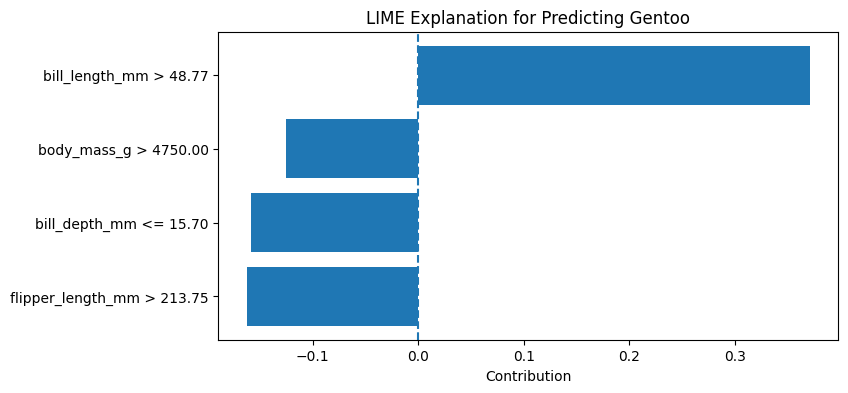

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
import matplotlib.pyplot as plt

# Create LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=model.classes_.tolist(),
    mode="classification"
)

# Explain same penguin
lime_exp = lime_explainer.explain_instance(
    data_row=penguin.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=4
)

# Convert LIME explanation to simple table
lime_df = pd.DataFrame(
    lime_exp.as_list(),
    columns=["Feature condition", "Contribution"]
)

display(lime_df)

# Simple bar chart
lime_df_sorted = lime_df.sort_values("Contribution")

plt.figure(figsize=(8, 4))
plt.barh(lime_df_sorted["Feature condition"], lime_df_sorted["Contribution"])
plt.axvline(0, linestyle="--")
plt.title(f"LIME Explanation for Predicting {predicted_species}")
plt.xlabel("Contribution")
plt.ylabel("")
plt.show()